# 02 · Analytic Pearson residuals

Mirrors the [rapids-singlecell Pearson-residuals tutorial](https://rapids-singlecell.readthedocs.io/en/latest/notebooks/02_pearson_residuals.html). Pearson residuals (Lause et al. 2021) are an alternative to log-normalization that models counts with a regularized negative binomial; the residuals feed directly into PCA. All on the Metal GPU via **metal-SingleCell**.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, scanpy as sc
import metalsinglecell as msc

## Load and QC

In [2]:
adata = sc.datasets.pbmc3k(); adata.var_names_make_unique()
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)
msc.pp.filter_cells(adata, min_genes=200)
msc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs.pct_counts_mt < 20].copy()
adata.layers['counts'] = adata.X.copy()
adata.shape

(2698, 13714)

## Highly variable genes from raw counts
The rapids tutorial uses `flavor='pearson_residuals'`; metal-SingleCell currently offers `seurat_v3` (the closest count-based selector), which also operates directly on the counts layer.

In [3]:
msc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3', layer='counts')
adata = adata[:, adata.var.highly_variable].copy()
adata.X = adata.layers['counts'].copy()   # residuals are computed from raw counts
adata.shape

(2698, 2000)

## Pearson residuals → PCA
`normalize_pearson_residuals` writes the residuals into `adata.X`; PCA then runs on them.

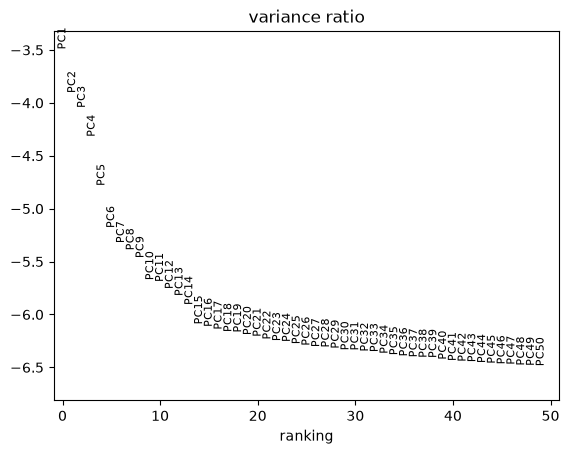

In [4]:
msc.pp.normalize_pearson_residuals(adata, theta=100.0)
msc.pp.pca(adata, n_comps=50, use_highly_variable=False)
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

## Neighbors, UMAP, Leiden on the residual PCA

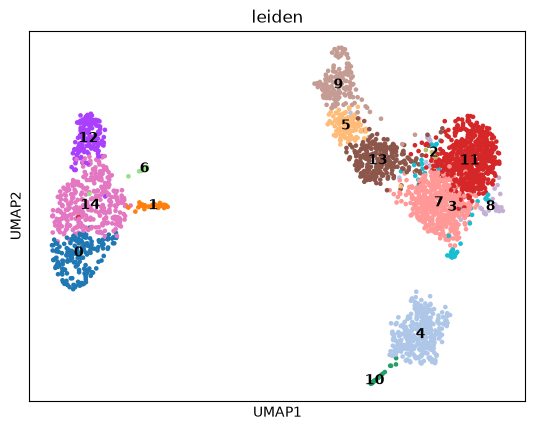

In [5]:
msc.pp.neighbors(adata, n_neighbors=15)
msc.tl.umap(adata)
msc.tl.leiden(adata, resolution=1.0, backend='gpu')
sc.pl.umap(adata, color=['leiden'], legend_loc='on data')

Pearson-residual normalization (no log1p, no scaling) produces a clustered embedding directly from counts — useful when sequencing depth varies strongly across cells.